In [1]:
# Limit to Cat3+ only ; Added Exel output

/tmp/ipykernel_28072/2667852115.py:166: DtypeWarning: Columns (21,66,128,143) have mixed types. Specify dtype option on import or set low_memory=False.
  sub_data_1 = pd.read_csv('../Data/IBTrACS_[Bourdin2022].csv')
/tmp/ipykernel_28072/2667852115.py:167: DtypeWarning: Columns (21,66,128,143) have mixed types. Specify dtype option on import or set low_memory=False.
  sub_data_2 = pd.read_csv('../Data/IBTrACS_[JTWC+HURDAT].csv')


  Basin  BasinOrder Experiment   Type Category  CategoryOrder  Count  \
0   Glb           1       f3-H  model       TS              1    712   
1   Glb           1      f3-HH  model       TS              1    629   
2   Glb           1       f3-L  model       TS              1    724   
3   Glb           1     IB-B22    obs       TS              1    348   
4   Glb           1      JT+HR    obs       TS              1    324   

   AnnualMean      Years  MinSteps  
0        71.2  1998-2007         8  
1        62.9  1998-2007         8  
2        72.4  1998-2007         8  
3        34.8  1998-2007         4  
4        32.4  1998-2007         4  
Experiment      IB-B22  JT+HR  f3-H  f3-HH  f3-L
Basin Category                                  
Glb   TS          34.8   32.4  71.2   62.9  72.4
      CAT1        13.8   14.8  48.0   45.9  50.6
      CAT2         7.3    5.6  21.1   20.0  13.5
      CAT3+       25.7   25.2  11.3   14.6   2.1
NA    TS           5.6    6.5  13.8   13.2  11.4
  

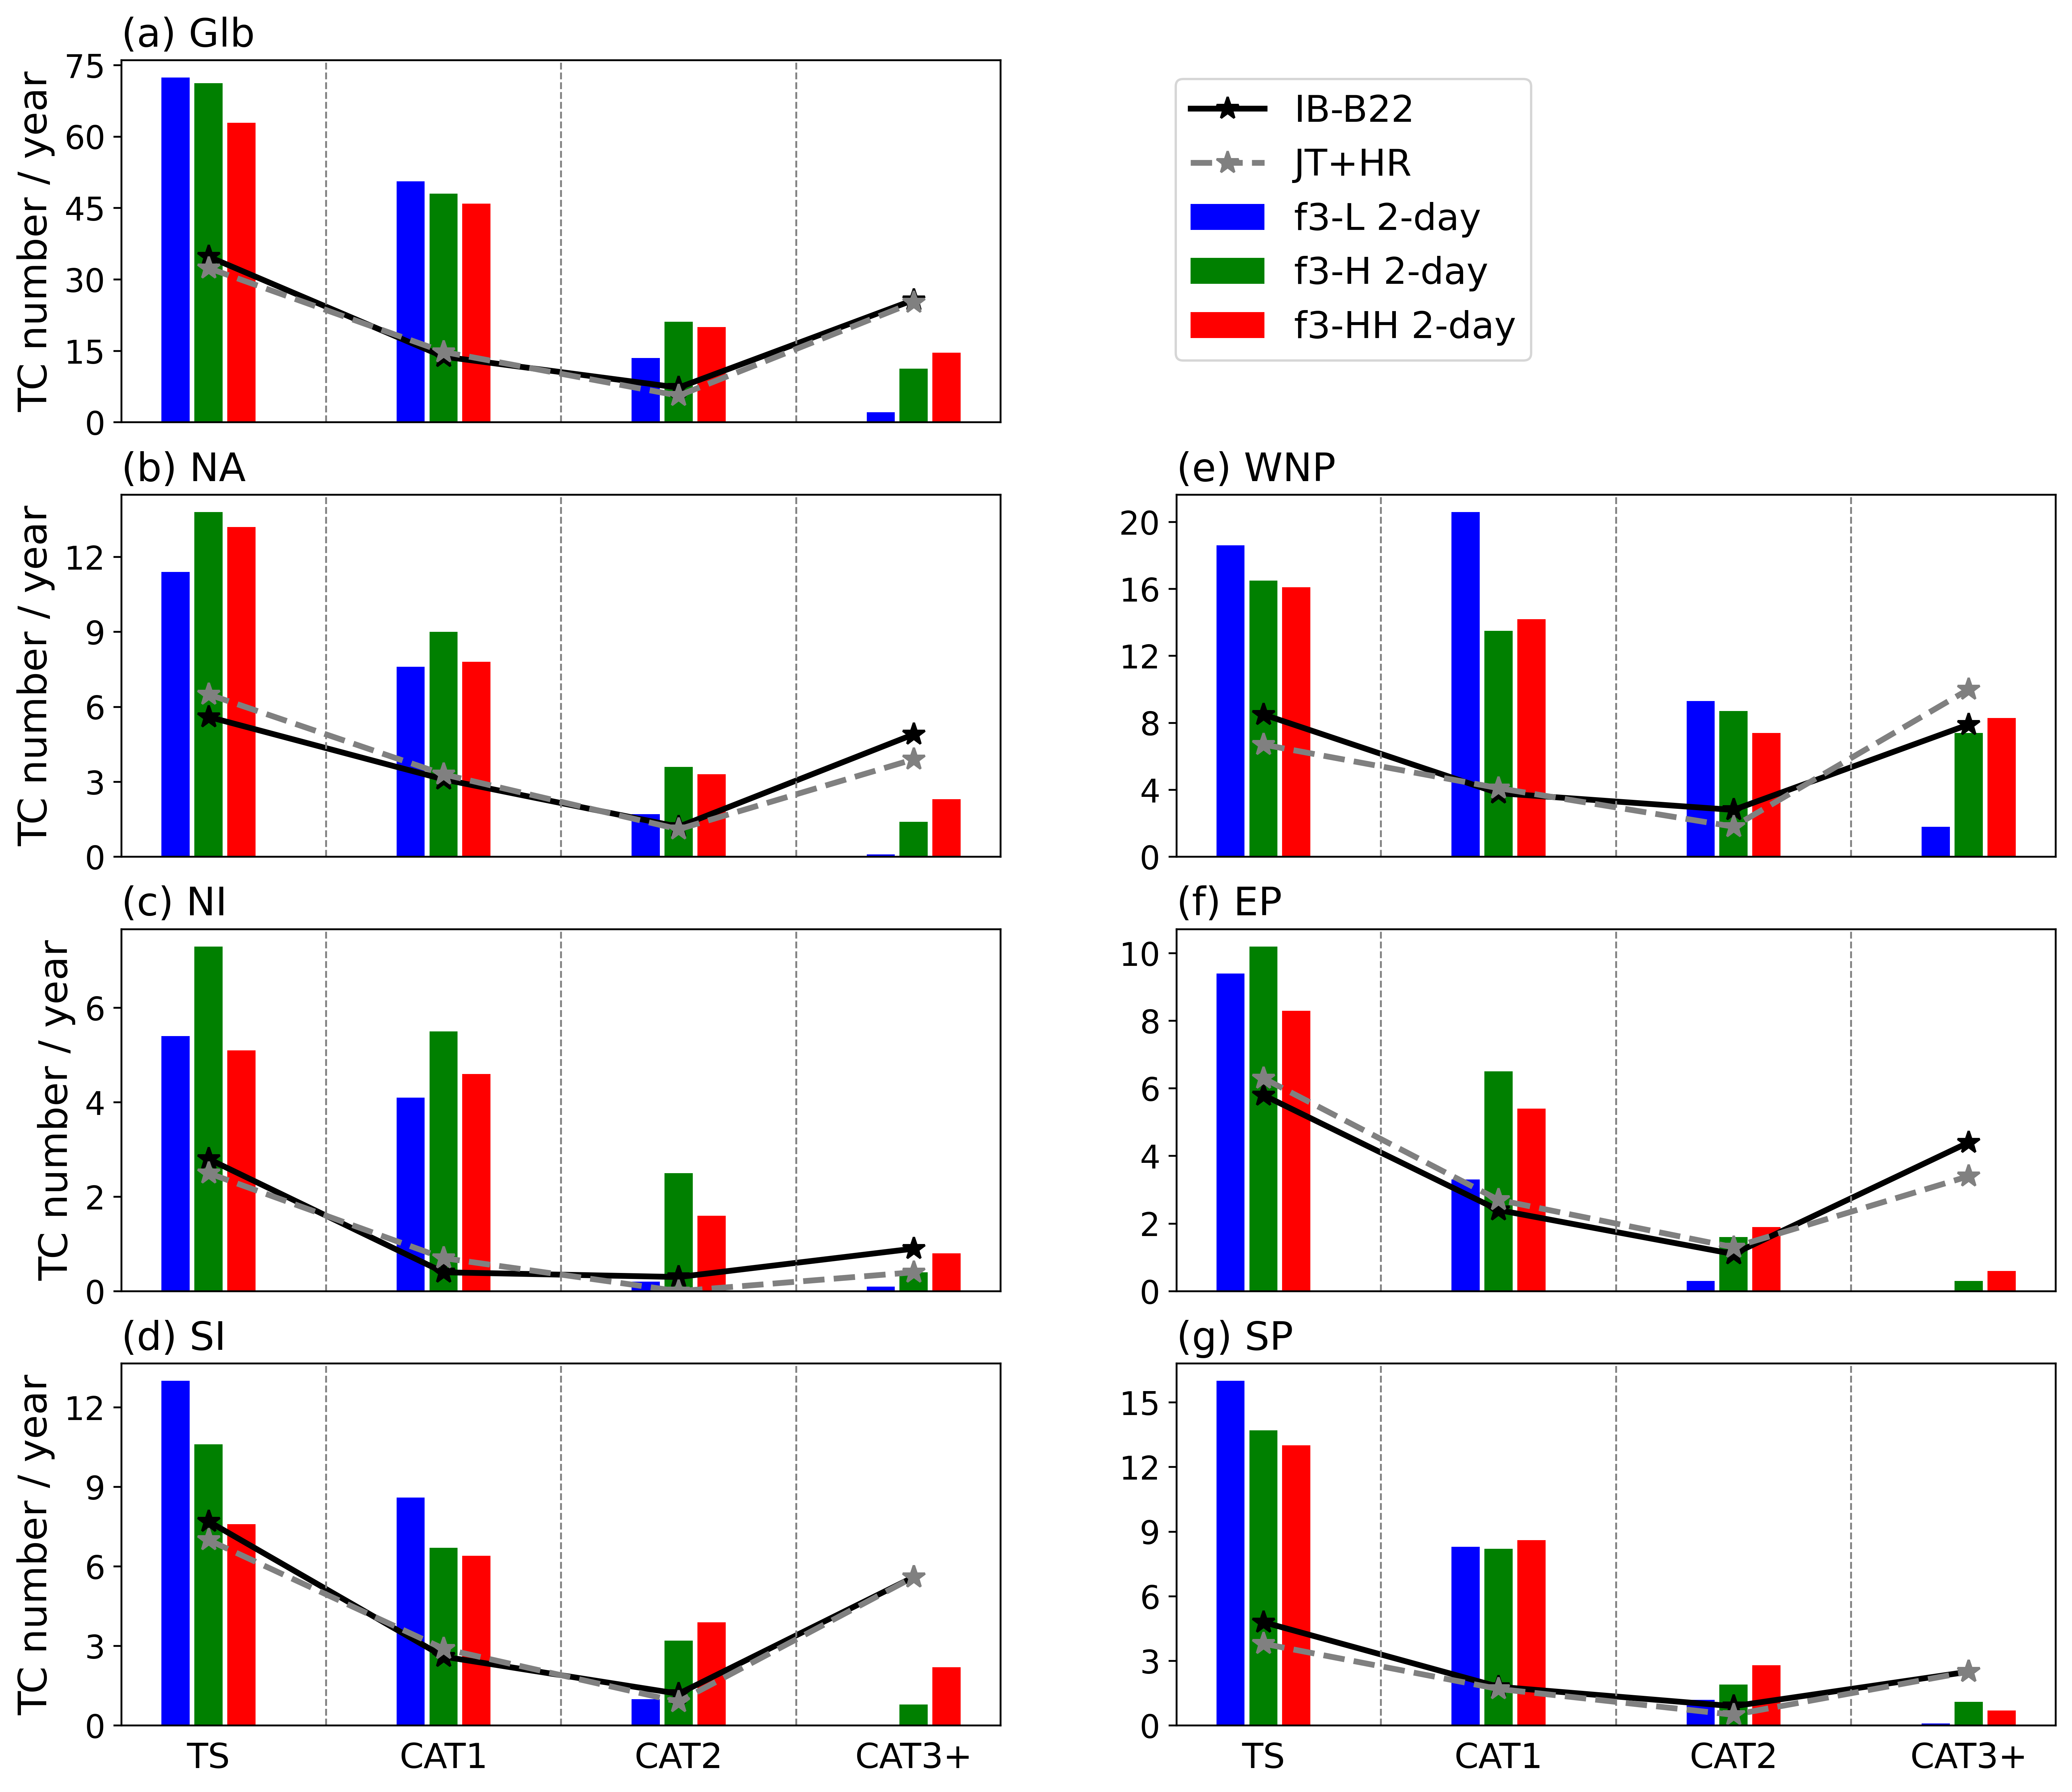

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import os

# =========================================================
# Basic settings
# =========================================================
start_year = 1998
end_year   = 2007
y_range    = np.arange(start_year, end_year + 1)
n_years    = len(y_range)

lon_min, lon_max = -180, 180
lat_min, lat_max = -50, 50

# fixed basin order for plot and Excel output
basins = ['Glb', 'NA', 'NI', 'SI', 'SA', 'WNP', 'EP', 'SP']
basin_order_map = {b: i + 1 for i, b in enumerate(basins)}

# observations: 1 day, models: 2 days
obs_mstep   = 4
model_mstep = 8

# Exclusive categories based on lifetime peak UNI_CAT
# TS:   1.9 <= UNI_CAT < 2.9
# CAT1: 2.9 <= UNI_CAT < 3.9
# CAT2: 3.9 <= UNI_CAT < 4.9
# CAT3: 4.9 <= UNI_CAT < 5.9
# CAT4: 5.9 <= UNI_CAT < 6.9
# CAT5: 6.9 <= UNI_CAT
cat_defs = [
    ('TS',   1.9, 2.9),
    ('CAT1', 2.9, 3.9),
    ('CAT2', 3.9, 4.9),
    ('CAT3+', 4.9, np.inf),
]
cat_labels = [x[0] for x in cat_defs]
cat_order_map = {c: i + 1 for i, c in enumerate(cat_labels)}

# =========================================================
# Helpers
# =========================================================
def trans_trim_dframe(df, lon_col='LON', lat_col='LAT', time_col='ISO_TIME',
                      start_year=None, end_year=None,
                      lon_min=None, lon_max=None, lat_min=None, lat_max=None):
    df = df.copy()

    # Convert longitude to (-180, 180]
    df[lon_col] = df[lon_col].apply(lambda lon: lon if lon <= 180 else lon - 360)

    # Add year
    df['YEAR'] = pd.to_datetime(df[time_col]).dt.year

    # Year filter
    if start_year is not None and end_year is not None:
        yr = range(start_year, end_year + 1)
        df = df[df['YEAR'].isin(yr)].copy()

    # Domain filter
    if lon_min is not None and lon_max is not None and lat_min is not None and lat_max is not None:
        df = df[
            (df[lon_col] >= lon_min) & (df[lon_col] <= lon_max) &
            (df[lat_col] >= lat_min) & (df[lat_col] <= lat_max)
        ].copy()

    return df


def point_in_polygon(lon, lat, polygon_path):
    return polygon_path.contains_point((lon, lat))


def basin_data(in_df, basin=None):
    df = in_df.copy()

    # Convert longitude to [-180, 180)
    df['LON'] = (df['LON'] + 180) % 360 - 180

    if basin is None:
        return df

    if basin == 'Glb':
        polygon_coords = np.array([[-180, 50], [-180, -50], [180, -50], [180, 50], [-180, 50]])
    elif basin == 'NA':
        polygon_coords = np.array([[-70, 0], [-100, 20], [-100, 50], [0, 50], [0, 0], [-70, 0]])
    elif basin == 'EP':
        polygon_coords = np.array([[-70, 0], [-100, 20], [-100, 50], [-180, 50], [-180, 0], [-70, 0]])
    elif basin == 'WNP':
        polygon_coords = np.array([[100, 0], [100, 50], [180, 50], [180, 0], [100, 0]])
    elif basin == 'NI':
        polygon_coords = np.array([[30, 0], [30, 50], [100, 50], [100, 0], [30, 0]])
    elif basin == 'SI':
        polygon_coords = np.array([[10, 0], [10, -50], [135, -50], [135, 0], [10, 0]])
    elif basin == 'SA':
        polygon_coords = np.array([[10, 0], [10, -50], [-70, -50], [-70, 0], [10, 0]])
    elif basin == 'SP':
        polygon_coords = np.array([[135, 0], [135, -50], [290, -50], [290, 0], [135, 0]])
    else:
        raise ValueError(f'Unknown basin: {basin}')

    polygon_path = Path(polygon_coords)

    if basin == 'SP':
        df['LON'] = (df['LON'] + 360) % 360
        mask = df.apply(lambda row: point_in_polygon(row['LON'], row['LAT'], polygon_path), axis=1)
        filtered_df = df.loc[mask].copy()
        filtered_df['LON'] = (filtered_df['LON'] + 180) % 360 - 180
    else:
        mask = df.apply(lambda row: point_in_polygon(row['LON'], row['LAT'], polygon_path), axis=1)
        filtered_df = df.loc[mask].copy()

    return filtered_df


def classify_peak_cat(peak_uni_cat, cat_defs):
    for label, lower, upper in cat_defs:
        if lower <= peak_uni_cat < upper:
            return label
    return None


def count_storms_by_peak_category(df, basin, min_steps, cat_defs):
    """
    Count each storm once, based on its lifetime peak UNI_CAT.

    A storm linked to the basin is classified into only one category:
    TS, CAT1, CAT2, CAT3, CAT4, or CAT5.
    """
    out = {label: 0 for label, _, _ in cat_defs}

    if df.empty or 'SID' not in df.columns:
        return out

    # identify storms linked to this basin
    basin_df = basin_data(df, basin)
    if basin_df.empty:
        return out

    basin_sids = set(basin_df['SID'].unique())

    for sid, storm_d in df.groupby('SID', sort=False):
        if sid not in basin_sids:
            continue

        # lifetime threshold on full track
        if len(storm_d) < min_steps:
            continue

        peak_uni_cat = storm_d['UNI_CAT'].max()
        peak_label = classify_peak_cat(peak_uni_cat, cat_defs)

        if peak_label is not None:
            out[peak_label] += 1

    return out


# =========================================================
# Load data
# =========================================================
sub_data_1 = pd.read_csv('../Data/IBTrACS_[Bourdin2022].csv')
sub_data_2 = pd.read_csv('../Data/IBTrACS_[JTWC+HURDAT].csv')
sub_data_3 = pd.read_csv('../Data/RV-f3L-w15.2_L2.0_Walsh.csv')
sub_data_4 = pd.read_csv('../Data/RV-f3H-w17.1_L2.0_Walsh.csv')
sub_data_5 = pd.read_csv('../Data/RV-f3HH-w17.4_L2.0_Walsh.csv')

# Trim / transform
sub_data_1 = trans_trim_dframe(sub_data_1, start_year=start_year, end_year=end_year,
                               lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max)
sub_data_2 = trans_trim_dframe(sub_data_2, start_year=start_year, end_year=end_year,
                               lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max)
sub_data_3 = trans_trim_dframe(sub_data_3, start_year=start_year, end_year=end_year,
                               lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max)
sub_data_4 = trans_trim_dframe(sub_data_4, start_year=start_year, end_year=end_year,
                               lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max)
sub_data_5 = trans_trim_dframe(sub_data_5, start_year=start_year, end_year=end_year,
                               lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max)

exp_configs = [
    {'name': 'IB-B22', 'df': sub_data_1, 'kind': 'obs',   'min_steps': obs_mstep,   'color': 'black', 'ls': '-',  'lw': 2.5},
    {'name': 'JT+HR',  'df': sub_data_2, 'kind': 'obs',   'min_steps': obs_mstep,   'color': 'gray',  'ls': '--', 'lw': 2.5},
    {'name': 'f3-L',   'df': sub_data_3, 'kind': 'model', 'min_steps': model_mstep, 'color': 'blue'},
    {'name': 'f3-H',   'df': sub_data_4, 'kind': 'model', 'min_steps': model_mstep, 'color': 'green'},
    {'name': 'f3-HH',  'df': sub_data_5, 'kind': 'model', 'min_steps': model_mstep, 'color': 'red'},
]

# =========================================================
# Count storms
# =========================================================
records = []

for basin in basins:
    for exp in exp_configs:
        counts = count_storms_by_peak_category(
            df=exp['df'],
            basin=basin,
            min_steps=exp['min_steps'],
            cat_defs=cat_defs
        )

        for cat in cat_labels:
            records.append({
                'Basin': basin,
                'BasinOrder': basin_order_map[basin],
                'Experiment': exp['name'],
                'Type': exp['kind'],
                'Category': cat,
                'CategoryOrder': cat_order_map[cat],
                'Count': counts[cat],
                'AnnualMean': counts[cat] / n_years,
                'Years': f'{start_year}-{end_year}',
                'MinSteps': exp['min_steps']
            })

df_counts = pd.DataFrame(records)

# enforce fixed order
df_counts['Basin'] = pd.Categorical(df_counts['Basin'], categories=basins, ordered=True)
df_counts['Category'] = pd.Categorical(df_counts['Category'], categories=cat_labels, ordered=True)

df_counts = df_counts.sort_values(
    ['BasinOrder', 'CategoryOrder', 'Type', 'Experiment']
).reset_index(drop=True)

# quick check
print(df_counts.head())
print(
    df_counts.pivot_table(
        index=['Basin', 'Category'],
        columns='Experiment',
        values='AnnualMean',
        sort=False
    )
)

# =========================================================
# Excel tables for later comparison
# =========================================================
os.makedirs('../Table', exist_ok=True)

# long table
df_long = df_counts.copy()

# annual mean pivot
df_pivot_mean = (
    df_counts
    .pivot_table(index=['BasinOrder', 'Basin', 'CategoryOrder', 'Category'],
                 columns='Experiment',
                 values='AnnualMean',
                 sort=False)
    .reset_index()
    .sort_values(['BasinOrder', 'CategoryOrder'])
    .reset_index(drop=True)
)

# total count pivot
df_pivot_count = (
    df_counts
    .pivot_table(index=['BasinOrder', 'Basin', 'CategoryOrder', 'Category'],
                 columns='Experiment',
                 values='Count',
                 sort=False)
    .reset_index()
    .sort_values(['BasinOrder', 'CategoryOrder'])
    .reset_index(drop=True)
)

excel_path = '../Table/Tab_S2_TC_climatology_exclusive_counts [2-day Cri] [CAT3+].xlsx'
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    df_pivot_mean.to_excel(writer, sheet_name='annual_mean_pivot', index=False)

print(f'Excel table saved as: {excel_path}')

# =========================================================
# Plot
# =========================================================
fig, axs = plt.subplots(4, 2, figsize=(15, 13))
fig.set_dpi(500)
panel_labels = ['(a)', '(b)', '(c)', '(d)', '()', '(e)', '(f)', '(g)']

x = np.arange(len(cat_labels))
bar_width = 0.14
gap = 0.02

model_names  = [e['name'] for e in exp_configs if e['kind'] == 'model']
model_colors = [e['color'] for e in exp_configs if e['kind'] == 'model']
obs_names    = [e['name'] for e in exp_configs if e['kind'] == 'obs']

for basin_idx, (basin, panel) in enumerate(zip(basins, panel_labels)):

    # keep SA empty as before
    if basin_idx == 4:
        continue

    row_idx = basin_idx % 4
    col_idx = basin_idx // 4
    ax = axs[row_idx, col_idx]

    basin_df = df_counts[df_counts['Basin'] == basin]

    # model bars
    for j, (name, color) in enumerate(zip(model_names, model_colors)):
        vals = (
            basin_df[basin_df['Experiment'] == name]
            .set_index('Category')
            .loc[cat_labels, 'AnnualMean']
            .values
        )

        offset = (j - 1) * bar_width
        ax.bar(x + offset, vals, width=bar_width - gap, color=color, label=name)

    # observation lines
    for name in obs_names:
        vals = (
            basin_df[basin_df['Experiment'] == name]
            .set_index('Category')
            .loc[cat_labels, 'AnnualMean']
            .values
        )

        exp_cfg = next(e for e in exp_configs if e['name'] == name)

        ax.plot(
            x, vals,
            color=exp_cfg['color'],
            linestyle=exp_cfg['ls'],
            linewidth=exp_cfg['lw'],
            marker='*',
            markersize=10,
            label=name
        )

    # formatting
    if col_idx == 0:
        ax.set_ylabel('TC number / year', fontsize=17)

    ax.set_xticks(x)
    if row_idx == 3:
        ax.set_xticklabels(cat_labels, fontsize=15)
    else:
        ax.set_xticklabels([])

    for k in range(1, len(cat_labels)):
        ax.axvline(x=k - 0.5, color='gray', linestyle='--', linewidth=0.8)

    ax.set_title(f'{panel} {basin}', fontsize=17, loc='left')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
    ax.tick_params(axis='y', labelsize=14)
    ax.tick_params(axis='x', which='both', bottom=False, top=False)

# remove empty axis
fig.delaxes(axs[0, 1])

legend_handles = [
    Line2D([0], [0], color='black', lw=2.5, ls='-',  marker='*', markersize=10, label='IB-B22'),
    Line2D([0], [0], color='gray',  lw=2.5, ls='--', marker='*', markersize=10, label='JT+HR'),
    Patch(facecolor='blue',  label='f3-L 2-day'),
    Patch(facecolor='green', label='f3-H 2-day'),
    Patch(facecolor='red',   label='f3-HH 2-day'),
]

fig.legend(handles=legend_handles, loc='upper left',
           bbox_to_anchor=(0.54, 0.88), fontsize=16)

# =========================================================
# Save figure
# =========================================================
# os.makedirs('../Figure', exist_ok=True)
# save_path = '../Figure/Tab_S2_Annual climatology of the number of TCs [2-day Cri] [Exclusive CAT] [CAT3+].pdf'
# plt.savefig(save_path, dpi=600, bbox_inches='tight', format='pdf')
# print(f'Figure saved as: {save_path}')

plt.show()